# Preprocessing Phase
- This phase will cover the cleaning of dataset for use in modelling.
- Since I decided not to drop rows with null values because they have other important metric present like `demand_count` etc, I will split the dataset into two samples, one cleaned (for modelling) and one with its original structure for visualizations.

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

In [108]:
# Import
DATASET_FILEPATH = '../../dataset/raw/'
DATASET_FILENAME = 'skill-scarcity-index.csv'
PROCESSED_DATASET_FILEPATH = '../../dataset/processed/'
FIGURES_FILEPATH = '../../figures'

# Pandas import
df = pd.read_csv(DATASET_FILEPATH+DATASET_FILENAME, index_col=0).reset_index(drop=True)

In [109]:
# First 10 Rows
df.head(10)

,category,skill_name,demand_count,demand_pct,median_days_open,salary_premium_pct,repost_rate_pct,scarcity_score
0,ai,A/B Testing,115,4.7,1.0,3.9,2.0,49.2
1,ai,Agile / Scrum,63,2.6,1.0,42.5,14.0,62.9
2,ai,AI Agents,153,6.3,NaN,45.5,5.9,72.0
3,ai,AI Coding Tools,32,1.3,NaN,NaN,0.0,0.0
4,ai,Airflow,54,2.2,9.0,-38.7,16.2,57.2
5,ai,AWS,259,10.6,0.0,-29.2,11.2,31.0
6,ai,Azure,221,9.0,0.0,-46.9,19.5,28.3
7,ai,BigQuery,43,1.8,4.0,NaN,22.2,75.5
8,ai,C#,42,1.7,0.0,-31.5,7.2,25.0
9,ai,C++,66,2.7,1.0,-10.9,18.0,60.4


In [96]:
# Drop Nulls on median_days_open and salary_premium_pct
df = df.dropna(subset=['median_days_open', 'salary_premium_pct'])

In [97]:
# Show rows that have null values in the 'median_days_open' column
null_median_days = df[df['median_days_open'].isnull()]
print(f"Number of rows with Null Values: {len(null_median_days)}")
null_median_days

Number of rows with Null Values: 0


,category,skill_name,demand_count,demand_pct,median_days_open,salary_premium_pct,repost_rate_pct,scarcity_score


In [98]:
# Show rows that have null values in the 'salary_premium_pct' 
null_salary_premium_pct = df[df['salary_premium_pct'].isnull()]
print(f"Number of rows with Null Values: {len(null_salary_premium_pct)}")
null_salary_premium_pct

Number of rows with Null Values: 0


,category,skill_name,demand_count,demand_pct,median_days_open,salary_premium_pct,repost_rate_pct,scarcity_score


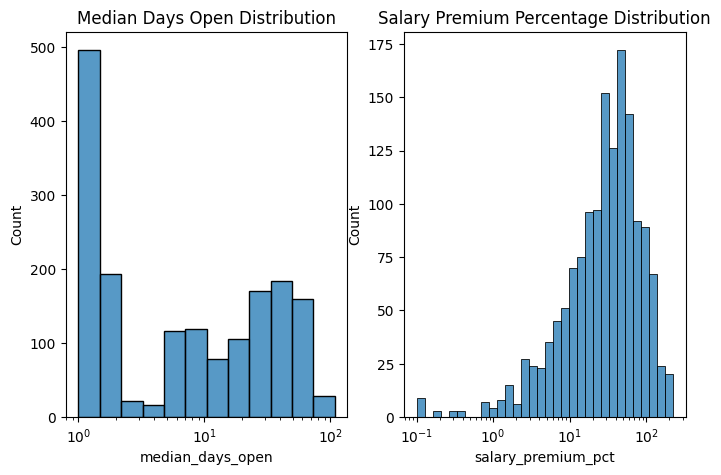

In [99]:
# Histogram Plotting 
fig, ax = plt.subplots(1,2,figsize=(8,5))

# log scaled histogram for demand count
sns.histplot(data=df, x='median_days_open', ax=ax[0], log_scale=True)
ax[0].set_title('Median Days Open Distribution')
plt.savefig(FIGURES_FILEPATH + '/preprocessing/median_days_open_distribution_log.png', dpi=300, bbox_inches='tight')

sns.histplot(data=df, x='salary_premium_pct', ax=ax[1], log_scale=True)
ax[1].set_title('Salary Premium Percentage Distribution')
plt.savefig(FIGURES_FILEPATH + '/preprocessing/salary_premium_pct_distribution_log.png', dpi=300, bbox_inches='tight')

In [100]:
# Log transform columns
df['log_median_days_open'] = np.log1p(df['median_days_open'])

We log transform the `median_days_open` column to fix the right skewness present in our data.
Log transformation compresses large values while pulling out the low ends.

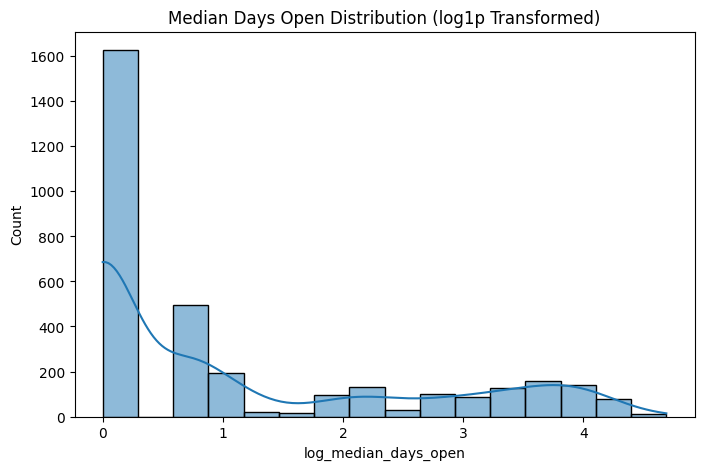

In [101]:
fig, ax = plt.subplots(1,1,figsize=(8,5))

# log scaled histogram for demand count
sns.histplot(data=df, x='log_median_days_open', ax=ax, kde=True)
ax.set_title('Median Days Open Distribution (log1p Transformed)')
plt.savefig(FIGURES_FILEPATH + '/preprocessing/log1p_median_days_open_distribution_log.png', dpi=300, bbox_inches='tight')

In [102]:
# Final Checks
null_values = df.isnull().sum()
print(f"Null Values in Each Column:\n{null_values}")

Null Values in Each Column:
category                0
skill_name              0
demand_count            0
demand_pct              0
median_days_open        0
salary_premium_pct      0
repost_rate_pct         0
scarcity_score          0
log_median_days_open    0
dtype: int64


In [103]:
# Drop categorical columns that are not needed for modeling
model_features = [
    'scarcity_score', 
    'salary_premium_pct', 
    'repost_rate_pct', 
    'demand_count', 
    'median_days_open',
    'log_median_days_open'
]

df_model = df[model_features]

# Export to csv
df_model.to_csv(PROCESSED_DATASET_FILEPATH+'model_dataset.csv', index=False)

Code below will create new dataset for processed dataset under `/datasets/processed/`.

In [104]:
# Load Separate DF
df1 = pd.read_csv(DATASET_FILEPATH+DATASET_FILENAME, index_col=1).reset_index(drop=True)

In [105]:
# Convert snapshot_date to year, day and month columns
df1['snapshot_date'] = pd.to_datetime(df1['snapshot_date'])
df1['year'] = df1['snapshot_date'].dt.year
df1['day'] = df1['snapshot_date'].dt.day
df1['month'] = df1['snapshot_date'].dt.month_name()

df1.head(10)

,snapshot_date,skill_name,demand_count,demand_pct,median_days_open,salary_premium_pct,repost_rate_pct,scarcity_score,year,day,month
0,2026-07-12,A/B Testing,115,4.7,1.0,3.9,2.0,49.2,2026,12,July
1,2026-07-12,Agile / Scrum,63,2.6,1.0,42.5,14.0,62.9,2026,12,July
2,2026-07-12,AI Agents,153,6.3,NaN,45.5,5.9,72.0,2026,12,July
3,2026-07-12,AI Coding Tools,32,1.3,NaN,NaN,0.0,0.0,2026,12,July
4,2026-07-12,Airflow,54,2.2,9.0,-38.7,16.2,57.2,2026,12,July
5,2026-07-12,AWS,259,10.6,0.0,-29.2,11.2,31.0,2026,12,July
6,2026-07-12,Azure,221,9.0,0.0,-46.9,19.5,28.3,2026,12,July
7,2026-07-12,BigQuery,43,1.8,4.0,NaN,22.2,75.5,2026,12,July
8,2026-07-12,C#,42,1.7,0.0,-31.5,7.2,25.0,2026,12,July
9,2026-07-12,C++,66,2.7,1.0,-10.9,18.0,60.4,2026,12,July


In [106]:

# Export to csv
df1.to_csv(PROCESSED_DATASET_FILEPATH+'skills-scarcity-index-processed.csv', index=False)